# Сравнение процедурных шумов

В данном ноутбуке проводится анализ процедурных шумов:
- Perlin
- Value
- Simplex
- их fBm-модификаций

Анализ проводится для трёх диапазонов частот:
- LOW
- MID
- HIGH

Используемые метрики:
- Энтропия
- Автокорреляция
- Время генерации

In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..")
CSV_PATH = PROJECT_ROOT / "report" / "metrics.csv"

df = pd.read_csv(CSV_PATH)
df


,frequency,method,entropy,autocorr,time_ms
0,low,Perlin,-1385.471101,0.337399,37.436
1,low,Value,-52.980438,0.660547,19.516
2,low,Simplex,-55.480774,0.996874,763.924
3,low,fBm-Perlin,-437.127955,0.425347,90.515
4,low,fBm-Value,-146.782777,0.712434,40.654
5,low,fBm-Simplex,-143.671749,0.995774,1711.189
6,mid,Perlin,-462.936011,0.768674,40.981
7,mid,Value,-43.183084,0.890084,19.078
8,mid,Simplex,-51.983622,0.993581,780.313
9,mid,fBm-Perlin,-363.498434,0.817126,193.936


In [2]:
df.sort_values(["frequency", "method"])

,frequency,method,entropy,autocorr,time_ms
12,high,Perlin,-226.714255,0.935984,42.778
14,high,Simplex,-45.190341,0.986104,843.708
13,high,Value,-36.702532,0.968333,19.340
15,high,fBm-Perlin,-353.905545,0.948967,288.022
17,high,fBm-Simplex,-213.893167,0.960278,4868.392
16,high,fBm-Value,-221.705214,0.972415,139.729
0,low,Perlin,-1385.471101,0.337399,37.436
2,low,Simplex,-55.480774,0.996874,763.924
1,low,Value,-52.980438,0.660547,19.516
3,low,fBm-Perlin,-437.127955,0.425347,90.515


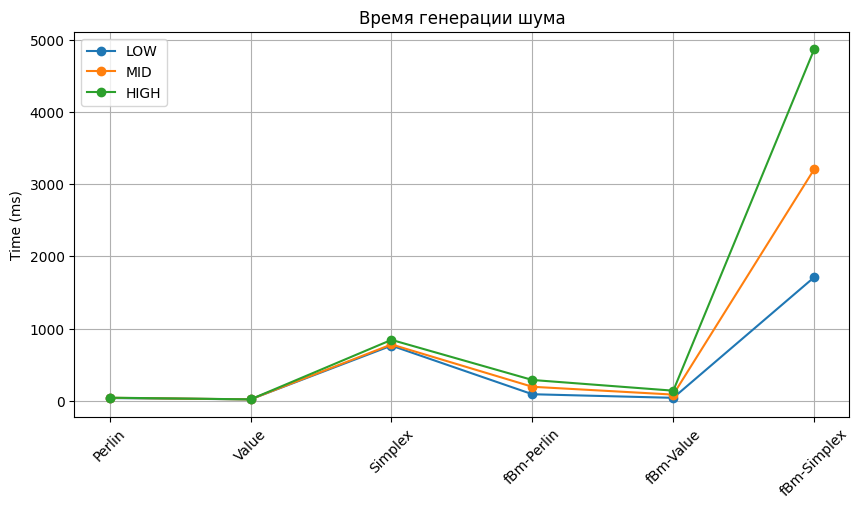

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for freq in df["frequency"].unique():
    subset = df[df["frequency"] == freq]
    plt.plot(
        subset["method"],
        subset["time_ms"],
        marker="o",
        label=freq.upper()
    )

plt.ylabel("Time (ms)")
plt.title("Время генерации шума")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

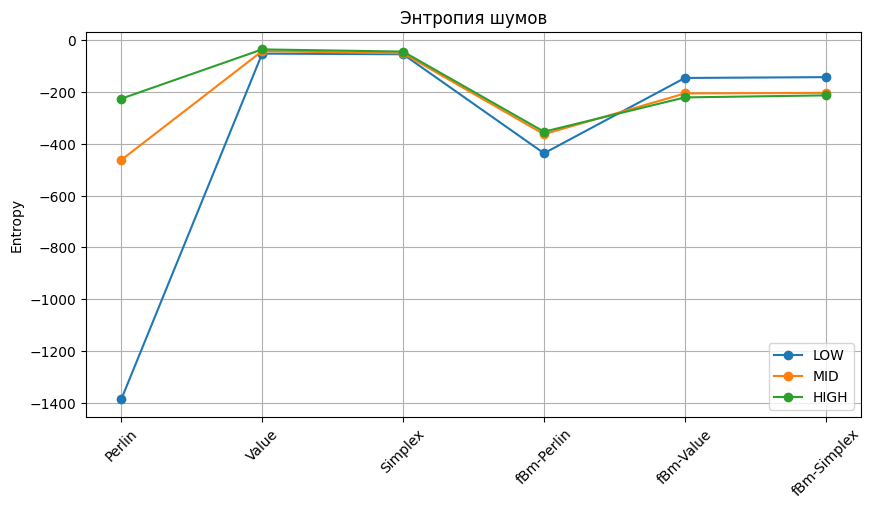

In [4]:
plt.figure(figsize=(10, 5))

for freq in df["frequency"].unique():
    subset = df[df["frequency"] == freq]
    plt.plot(
        subset["method"],
        subset["entropy"],
        marker="o",
        label=freq.upper()
    )

plt.ylabel("Entropy")
plt.title("Энтропия шумов")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

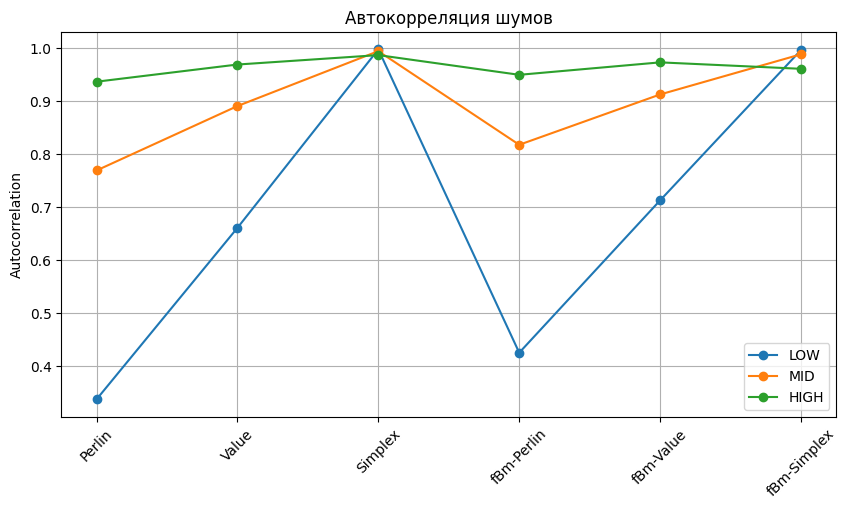

In [5]:
plt.figure(figsize=(10, 5))

for freq in df["frequency"].unique():
    subset = df[df["frequency"] == freq]
    plt.plot(
        subset["method"],
        subset["autocorr"],
        marker="o",
        label=freq.upper()
    )

plt.ylabel("Autocorrelation")
plt.title("Автокорреляция шумов")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Визуальные примеры шумов и их FFT-спектров приведены в приложении (PDF).

## Выводы

1. Value Noise демонстрирует наименьшее время генерации среди рассмотренных методов,
   однако характеризуется меньшей пространственной корреляцией.
2. Simplex Noise обеспечивает высокую гладкость и коррелированность шума,
   но требует значительно больших вычислительных затрат.
3. Применение фрактального броуновского движения (fBm) повышает
   детализированность текстур, при этом существенно увеличивая время генерации,
   особенно при использовании Simplex Noise.
4. Спектральный анализ с использованием FFT подтверждает различие
   частотных характеристик различных типов шума.
5. Выбор метода генерации процедурного шума должен осуществляться
   исходя из требований к визуальному качеству и производительности.